# Лабораторная работа №7. Полносвязные нейронные сети (FCNN).
# Решение задачи классификации

## 1. Установка зависимостей

In [46]:
!pip install -q setuptools hyperopt optuna keras-tuner "ray[tune]" tensorflow


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Импорты

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
sklearn.set_config(display="text")

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import tensorflow as tf
import keras_tuner as kt


import os, multiprocessing
N_CORES = multiprocessing.cpu_count()
os.environ['OMP_NUM_THREADS']      = str(N_CORES)
os.environ['MKL_NUM_THREADS']      = str(N_CORES)
os.environ['OPENBLAS_NUM_THREADS'] = str(N_CORES)
tf.config.threading.set_intra_op_parallelism_threads(N_CORES)
tf.config.threading.set_inter_op_parallelism_threads(N_CORES)

## 2. Загрузка и подготовка данных

### 2.1 Загрузка датасета

Датасет: **asteroids_cleaned** — характеристики астероидов, сближающихся с Землёй. Задача: бинарная классификация — предсказание опасности астероида (`hazardous`).

**Признаки:** year, est_diameter_max, relative_velocity, miss_distance, absolute_magnitude (5 признаков).

**Дисбаланс классов:** ~90% безопасных (класс 0) и ~10% опасных (класс 1), соотношение ~9.3:1. Для корректного обучения применяются взвешивание классов (`sample_weight` / `class_weight`) и стратифицированная кросс-валидация (`StratifiedKFold`).

In [48]:
# Загрузка данных из локального файла
df = pd.read_csv('asteroids_cleaned.csv')
print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(3)

Датасет загружен: 88534 строк, 6 столбцов


,year,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.035813,56014.078517,1.024333e+06,26.1,0
1,2020,0.068240,7864.348060,3.268186e+07,24.7,0
2,2016,0.124177,55257.544508,6.538636e+07,23.4,0


### 2.3 Определение целевой переменной и анализ дисбаланса классов

Кол-во классов: 2
Бинарная классификация: True

Распределение классов:
  Класс 0 (безопасный):  79938  (90.3%)
  Класс 1 (опасный):      8596  (9.7%)
  Соотношение: 9.3:1 — сильный дисбаланс

Веса классов (balanced): {0: 0.5537666691686056, 1: 5.1497208003722665}


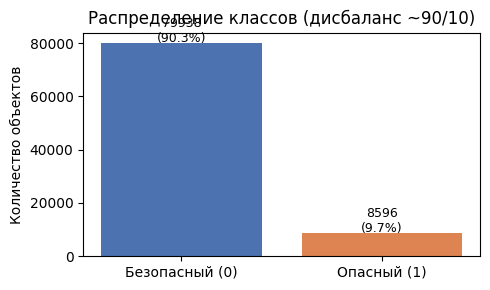

In [49]:
X = df.drop(columns=['hazardous'])
y = df['hazardous']

N_CLASSES = y.nunique()
print(f'Кол-во классов: {N_CLASSES}')
IS_BINARY = (N_CLASSES == 2)
print(f'Бинарная классификация: {IS_BINARY}')

# Анализ дисбаланса классов
vc = y.value_counts().sort_index()
print(f'\nРаспределение классов:')
print(f'  Класс 0 (безопасный): {vc[0]:>6}  ({100*vc[0]/len(y):.1f}%)')
print(f'  Класс 1 (опасный):    {vc[1]:>6}  ({100*vc[1]/len(y):.1f}%)')
print(f'  Соотношение: {vc[0]/vc[1]:.1f}:1 — сильный дисбаланс')

# Вычисление весов классов
from sklearn.utils.class_weight import compute_class_weight
cw_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
CLASS_WEIGHT_DICT = {0: float(cw_arr[0]), 1: float(cw_arr[1])}
print(f'\nВеса классов (balanced): {CLASS_WEIGHT_DICT}')

# Визуализация
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Безопасный (0)', 'Опасный (1)'], [vc[0], vc[1]],
              color=['#4c72b0', '#dd8452'])
ax.set_title('Распределение классов (дисбаланс ~90/10)')
ax.set_ylabel('Количество объектов')
for bar, val in zip(bars, [vc[0], vc[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val}\n({100*val/len(y):.1f}%)', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### 2.4 Оптимизация признакового пространства (RFE)

Метод: **Recursive Feature Elimination (RFE)** на основе DecisionTreeClassifier.

Датасет содержит 5 числовых признаков — RFE выбирает `min(10, 5) = 5` (все признаки сохраняются).

In [50]:
N_SELECT = min(10, X.shape[1])
estimator = DecisionTreeClassifier(random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=N_SELECT, step=1)
X_opt = pd.DataFrame(rfe.fit_transform(X, y), columns=X.columns[rfe.support_])

print(f"Исходное число признаков: {X.shape[1]}")
print(f"После RFE: {X_opt.shape[1]}")
print(f"\nВыбранные признаки: {list(X_opt.columns)}")


Исходное число признаков: 5
После RFE: 5

Выбранные признаки: ['year', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']


Из результатов лабораторной работы 6 можно понять, что признаки нельзя сокращать, так как их и так мало в датасете классификации и любое удаление приведет к потери части дисперсии.

### 2.5 Разделение данных, масштабирование и Stratified K-Fold

При дисбалансе классов используется `StratifiedKFold` — он гарантирует сохранение пропорций классов (~90/10) в каждом фолде.

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight

X_train, X_test, y_train, y_test = train_test_split(
    X_opt, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train_s, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# StratifiedKFold для сохранения пропорций дисбалансных классов
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# sample_weight для Sklearn MLP (не поддерживает class_weight напрямую)
sample_weight_train = compute_sample_weight('balanced', y_train)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print(f'Val (для Keras): {X_val.shape}')
print('StratifiedKFold: 5 фолдов')
print(f'Train class ratio: {(y_train==1).sum()}/{(y_train==0).sum()} '
      f'= {(y_train==1).sum()/(y_train==0).sum():.3f}')

Train: (70827, 5), Test: (17707, 5)
Val (для Keras): (10625, 5)
StratifiedKFold: 5 фолдов
Train class ratio: 6877/63950 = 0.108


## Вспомогательные функции

In [52]:
def compute_metrics(y_true, y_pred, y_prob=None):
    avg = 'binary' if IS_BINARY else 'macro'
    m = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred, average=avg, zero_division=0),
        'Precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average=avg, zero_division=0),
    }
    if y_prob is not None and IS_BINARY:
        m['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return m

def print_metrics(y_tr, y_tr_pred, y_te, y_te_pred,
                  model_name, epochs=None, optimizer=None,
                  y_tr_prob=None, y_te_prob=None):
    from IPython.display import display
    tr = compute_metrics(y_tr, y_tr_pred, y_tr_prob)
    te = compute_metrics(y_te, y_te_pred, y_te_prob)

    parts = [f'Модель: {model_name}']
    if epochs:    parts.append(f'Эпохи: {epochs}')
    if optimizer: parts.append(f'Оптимизатор: {optimizer}')
    print('  |  '.join(parts))

    df_m = pd.DataFrame({'Train': tr, 'Test': te}).round(4)
    display(df_m)
    return tr, te

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def plot_history(history_dict, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_dict['loss'], label='Train loss', color='#1f77b4')
    if 'val_loss' in history_dict:
        axes[0].plot(history_dict['val_loss'], label='Val loss', color='#ff7f0e', linestyle='--')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)
    acc_key = 'accuracy' if 'accuracy' in history_dict else None
    if acc_key:
        axes[1].plot(history_dict['accuracy'],     label='Train Acc', color='#2ca02c')
        axes[1].plot(history_dict.get('val_accuracy', []), label='Val Acc', color='#d62728', linestyle='--')
        axes[1].set_title(f'{title} — Accuracy')
        axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

def plot_sklearn_loss(model, title):
    """
    Строит кривую потерь sklearn MLP.
    • adam/sgd  — loss_curve_ доступна напрямую.
    • lbfgs     — L-BFGS-B: полно-пакетный квазиньютоновский метод,
                  не записывает loss_curve_ (нет мини-батчей).
                  Аппроксимация: обучаем ту же архитектуру с
                  нарастающим max_iter и записываем model.loss_.
    """
    if hasattr(model, 'loss_curve_') and model.loss_curve_ is not None:
        plt.figure(figsize=(7, 4))
        plt.plot(model.loss_curve_, color='#1f77b4', label='Train loss')
        plt.title(f'{title} — Кривая потерь')
        plt.xlabel('Итерация'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True); plt.show()
    elif hasattr(model, 'solver') and model.solver == 'lbfgs':
        print(f'[{title}] solver=lbfgs не логирует loss_curve_ — строим аппроксимацию...')
        max_it = max(getattr(model, 'n_iter_', 100), 20)
        iters  = list(dict.fromkeys(map(int, np.linspace(2, max_it, 15))))
        try:    sw = sample_weight_train
        except NameError: sw = None
        losses = []
        for n in iters:
            tmp = MLPClassifier(
                hidden_layer_sizes=model.hidden_layer_sizes,
                activation=model.activation,
                solver='lbfgs', alpha=model.alpha,
                max_iter=n, random_state=42
            )
            tmp.fit(X_train_s, y_train, sample_weight=sw)
            losses.append(tmp.loss_)
        plt.figure(figsize=(7, 4))
        plt.plot(iters, losses, color='#1f77b4', marker='o', markersize=4, label='Train loss')
        plt.title(f'{title} — Аппроксимация кривой потерь (lbfgs)')
        plt.xlabel('max_iter'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f'[{title}] График недоступен.')

results = []
print("Вспомогательные функции определены.")

Вспомогательные функции определены.


## 3. Решение задачи классификации с помощью FCNN

### 3.1 FCNN (MLP) из библиотеки Scikit-learn

In [53]:
ARCHITECTURES = [(64, 32), (128, 64), (64, 32, 16), (32, 16), (128, 64, 32)]
SOLVERS       = ['adam', 'sgd', 'lbfgs']
ACTIVATIONS   = ['relu', 'tanh']
print(f"Архитектуры: {ARCHITECTURES}")
print(f"Солверы: {SOLVERS}")


Архитектуры: [(64, 32), (128, 64), (64, 32, 16), (32, 16), (128, 64, 32)]
Солверы: ['adam', 'sgd', 'lbfgs']


#### 3.1.1 Метод 1: RandomizedSearchCV

In [54]:
param_dist_rs = {
    'hidden_layer_sizes': ARCHITECTURES,
    'solver':             SOLVERS,
    'activation':         ACTIVATIONS,
    'alpha':              [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-3, 1e-2],
    'max_iter':           [300],
}

rs_search = RandomizedSearchCV(
    MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1),
    param_distributions=param_dist_rs,
    n_iter=8,
    cv=kf,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rs_search.fit(X_train_s, y_train, sample_weight=sample_weight_train)
best_rs = rs_search.best_estimator_
best_rs.fit(X_train_s, y_train)
print(f'Лучшие параметры: {rs_search.best_params_}')

Лучшие параметры: {'solver': 'lbfgs', 'max_iter': 300, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.01, 'activation': 'relu'}


Архитектура (RandomizedSearchCV)
  hidden_layer_sizes : (64, 32, 16)
  activation         : relu
  solver             : lbfgs
  n_iter_            : 300
[Sklearn MLP (RandomizedSearchCV)] solver=lbfgs не логирует loss_curve_ — строим аппроксимацию...


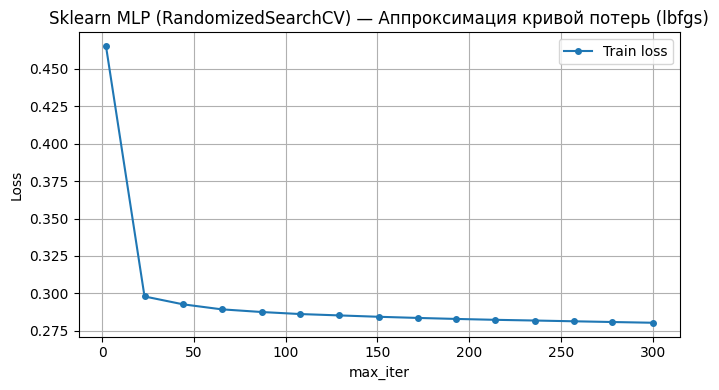

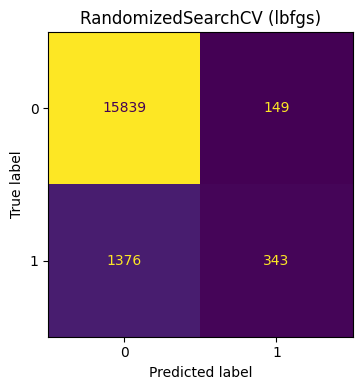

Модель: Sklearn MLP (RandomizedSearchCV, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
Accuracy,0.9157,0.9139
F1,0.3184,0.3103
Precision,0.7397,0.6972
Recall,0.2029,0.1995
ROC-AUC,0.9249,0.9211


In [55]:
print("Архитектура (RandomizedSearchCV)")
print(f"  hidden_layer_sizes : {best_rs.hidden_layer_sizes}")
print(f"  activation         : {best_rs.activation}")
print(f"  solver             : {best_rs.solver}")
print(f"  n_iter_            : {best_rs.n_iter_}")

plot_sklearn_loss(best_rs, "Sklearn MLP (RandomizedSearchCV)")
plot_confusion(y_test, best_rs.predict(X_test_s), f"RandomizedSearchCV ({best_rs.solver})")

y_tr_prob_rs = best_rs.predict_proba(X_train_s)[:, 1] if IS_BINARY else None
y_te_prob_rs = best_rs.predict_proba(X_test_s)[:, 1]  if IS_BINARY else None

tr_rs, te_rs = print_metrics(
    y_train, best_rs.predict(X_train_s),
    y_test,  best_rs.predict(X_test_s),
    model_name=f"Sklearn MLP (RandomizedSearchCV, solver={best_rs.solver})",
    epochs=best_rs.n_iter_, optimizer=best_rs.solver,
    y_tr_prob=y_tr_prob_rs, y_te_prob=y_te_prob_rs
)
results.append({
    'Классификатор/Фреймворк': f'Sklearn MLP — RandomizedSearchCV ({best_rs.solver})',
    'Train Acc':  tr_rs['Accuracy'],  'Train F1':   tr_rs['F1'],
    'Train Prec': tr_rs['Precision'], 'Train Rec':  tr_rs['Recall'],
    'Test Acc':   te_rs['Accuracy'],  'Test F1':    te_rs['F1'],
    'Test Prec':  te_rs['Precision'], 'Test Rec':   te_rs['Recall'],
    'Эпохи': best_rs.n_iter_, 'Оптимизатор': best_rs.solver
})

#### 3.1.2 Метод 2: Optuna

In [ ]:
def objective_sk_optuna(trial):
    arch_idx   = trial.suggest_int('arch_idx', 0, len(ARCHITECTURES) - 1)
    solver     = trial.suggest_categorical('solver',     SOLVERS)
    activation = trial.suggest_categorical('activation', ACTIVATIONS)
    alpha      = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    lr         = trial.suggest_float('lr',    1e-4, 1e-1, log=True)

    model = MLPClassifier(
        hidden_layer_sizes=ARCHITECTURES[arch_idx],
        solver=solver, activation=activation,
        alpha=alpha, learning_rate_init=lr,
        max_iter=300, random_state=42,
        early_stopping=True, validation_fraction=0.1
    )
    try:
        scores = cross_val_score(model, X_train_s, y_train, cv=kf,
                                 scoring='f1', n_jobs=-1, error_score='raise',
                                 params={'sample_weight': sample_weight_train})
        return -scores.mean() if not np.isnan(scores).any() else float('inf')
    except Exception:
        return float('inf')

study_sk = optuna.create_study(direction='minimize')
study_sk.optimize(objective_sk_optuna, n_trials=20,
                  catch=(ValueError, FloatingPointError))

bp = study_sk.best_params
print(f'Лучшие параметры: {bp}')

best_optuna_sk = MLPClassifier(
    hidden_layer_sizes=ARCHITECTURES[bp['arch_idx']],
    solver=bp['solver'], activation=bp['activation'],
    alpha=bp['alpha'], learning_rate_init=bp['lr'],
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
# Обучаем с sample_weight для учёта дисбаланса классов
best_optuna_sk.fit(X_train_s, y_train, sample_weight=sample_weight_train)

Лучшие параметры: {'arch_idx': 4, 'solver': 'lbfgs', 'activation': 'tanh', 'alpha': 0.0007515112463455627, 'lr': 0.0008580135267186997}


MLPClassifier(activation='tanh', alpha=0.0007515112463455627,
              early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              learning_rate_init=0.0008580135267186997, max_iter=300,
              random_state=42, solver='lbfgs')

Архитектура (Optuna Sklearn)
  hidden_layer_sizes : (128, 64, 32)
  activation         : tanh
  solver             : lbfgs
  n_iter_            : 300
[Sklearn MLP (Optuna)] solver=lbfgs не логирует loss_curve_ — строим аппроксимацию...


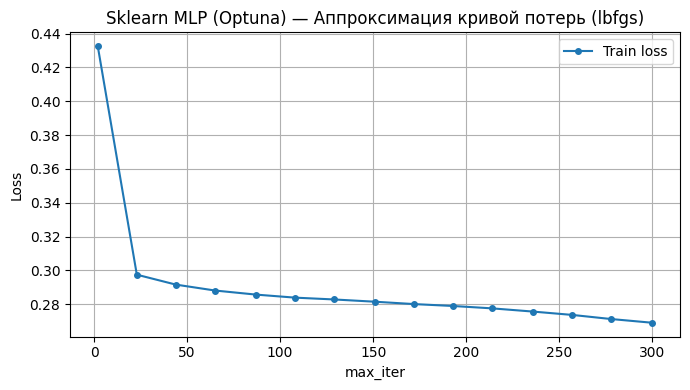

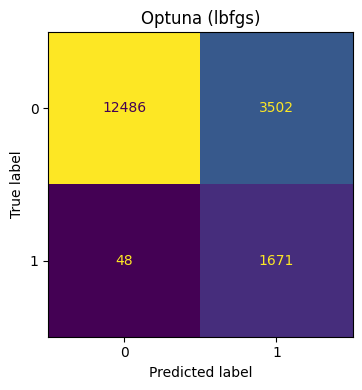

Модель: Sklearn MLP (Optuna, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
Accuracy,0.8026,0.7995
F1,0.4940,0.4849
Precision,0.3289,0.3230
Recall,0.9923,0.9721
ROC-AUC,0.9306,0.9212


In [57]:
print("Архитектура (Optuna Sklearn)")
print(f"  hidden_layer_sizes : {best_optuna_sk.hidden_layer_sizes}")
print(f"  activation         : {best_optuna_sk.activation}")
print(f"  solver             : {best_optuna_sk.solver}")
print(f"  n_iter_            : {best_optuna_sk.n_iter_}")

plot_sklearn_loss(best_optuna_sk, "Sklearn MLP (Optuna)")
plot_confusion(y_test, best_optuna_sk.predict(X_test_s), f"Optuna ({best_optuna_sk.solver})")

y_tr_prob_opt = best_optuna_sk.predict_proba(X_train_s)[:, 1] if IS_BINARY else None
y_te_prob_opt = best_optuna_sk.predict_proba(X_test_s)[:, 1]  if IS_BINARY else None

tr_opt_sk, te_opt_sk = print_metrics(
    y_train, best_optuna_sk.predict(X_train_s),
    y_test,  best_optuna_sk.predict(X_test_s),
    model_name=f"Sklearn MLP (Optuna, solver={best_optuna_sk.solver})",
    epochs=best_optuna_sk.n_iter_, optimizer=best_optuna_sk.solver,
    y_tr_prob=y_tr_prob_opt, y_te_prob=y_te_prob_opt
)
results.append({
    'Классификатор/Фреймворк': f'Sklearn MLP — Optuna ({best_optuna_sk.solver})',
    'Train Acc':  tr_opt_sk['Accuracy'],  'Train F1':   tr_opt_sk['F1'],
    'Train Prec': tr_opt_sk['Precision'], 'Train Rec':  tr_opt_sk['Recall'],
    'Test Acc':   te_opt_sk['Accuracy'],  'Test F1':    te_opt_sk['F1'],
    'Test Prec':  te_opt_sk['Precision'], 'Test Rec':   te_opt_sk['Recall'],
    'Эпохи': best_optuna_sk.n_iter_, 'Оптимизатор': best_optuna_sk.solver
})

#### 3.1.3 Метод 3: Hyperopt

In [58]:
space_ho = {
    'arch_idx':   hp.choice('arch_idx',   list(range(len(ARCHITECTURES)))),
    'solver':     hp.choice('solver',     SOLVERS),
    'activation': hp.choice('activation', ACTIVATIONS),
    'alpha':      hp.loguniform('alpha',  -9.2, -2.3),
    'lr':         hp.loguniform('lr',     -9.2, -2.3),
}

def objective_sk_ho(params):
    model = MLPClassifier(
        hidden_layer_sizes=ARCHITECTURES[params['arch_idx']],
        solver=params['solver'],
        activation=params['activation'],
        alpha=params['alpha'], learning_rate_init=params['lr'],
        max_iter=300, random_state=42,
        early_stopping=True, validation_fraction=0.1
    )
    scores = cross_val_score(model, X_train_s, y_train, cv=kf,
                             scoring='f1', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}

trials_ho = Trials()
best_ho = fmin(fn=objective_sk_ho, space=space_ho, algo=tpe.suggest,
               max_evals=20, trials=trials_ho,
               rstate=np.random.default_rng(42))

best_hyperopt_sk = MLPClassifier(
    hidden_layer_sizes=ARCHITECTURES[best_ho['arch_idx']],
    solver=SOLVERS[best_ho['solver']],
    activation=ACTIVATIONS[best_ho['activation']],
    alpha=best_ho['alpha'], learning_rate_init=best_ho['lr'],
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
# Обучаем с sample_weight для учёта дисбаланса классов
best_hyperopt_sk.fit(X_train_s, y_train, sample_weight=sample_weight_train)
print(f'Лучший solver: {best_hyperopt_sk.solver}')

100%|██████████| 20/20 [11:15<00:00, 33.79s/trial, best loss: -0.3265749279079112]
Лучший solver: lbfgs


Архитектура (Hyperopt Sklearn)
  hidden_layer_sizes : (128, 64)
  activation         : relu
  solver             : lbfgs
  n_iter_            : 300
[Sklearn MLP (Hyperopt)] solver=lbfgs не логирует loss_curve_ — строим аппроксимацию...


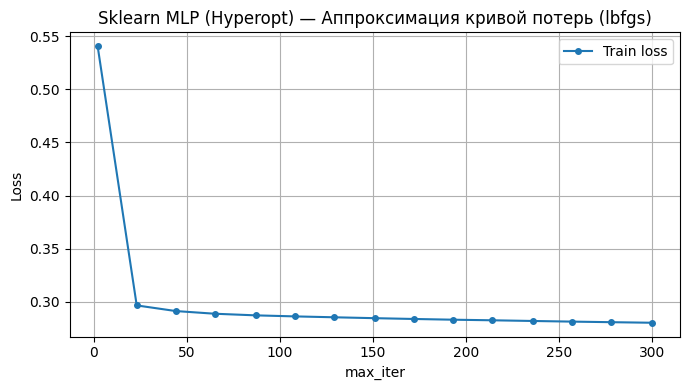

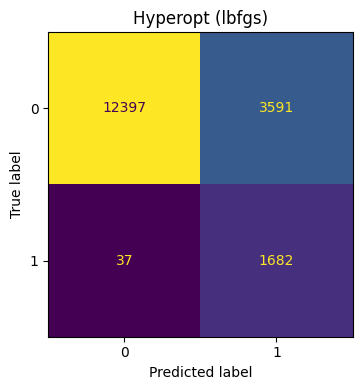

Модель: Sklearn MLP (Hyperopt, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
Accuracy,0.7949,0.7951
F1,0.4837,0.4811
Precision,0.3201,0.3190
Recall,0.9895,0.9785
ROC-AUC,0.9265,0.9217


In [59]:
print("Архитектура (Hyperopt Sklearn)")
print(f"  hidden_layer_sizes : {best_hyperopt_sk.hidden_layer_sizes}")
print(f"  activation         : {best_hyperopt_sk.activation}")
print(f"  solver             : {best_hyperopt_sk.solver}")
print(f"  n_iter_            : {best_hyperopt_sk.n_iter_}")

plot_sklearn_loss(best_hyperopt_sk, "Sklearn MLP (Hyperopt)")
plot_confusion(y_test, best_hyperopt_sk.predict(X_test_s), f"Hyperopt ({best_hyperopt_sk.solver})")

y_tr_prob_ho = best_hyperopt_sk.predict_proba(X_train_s)[:, 1] if IS_BINARY else None
y_te_prob_ho = best_hyperopt_sk.predict_proba(X_test_s)[:, 1]  if IS_BINARY else None

tr_ho_sk, te_ho_sk = print_metrics(
    y_train, best_hyperopt_sk.predict(X_train_s),
    y_test,  best_hyperopt_sk.predict(X_test_s),
    model_name=f"Sklearn MLP (Hyperopt, solver={best_hyperopt_sk.solver})",
    epochs=best_hyperopt_sk.n_iter_, optimizer=best_hyperopt_sk.solver,
    y_tr_prob=y_tr_prob_ho, y_te_prob=y_te_prob_ho
)
results.append({
    'Классификатор/Фреймворк': f'Sklearn MLP — Hyperopt ({best_hyperopt_sk.solver})',
    'Train Acc':  tr_ho_sk['Accuracy'],  'Train F1':   tr_ho_sk['F1'],
    'Train Prec': tr_ho_sk['Precision'], 'Train Rec':  tr_ho_sk['Recall'],
    'Test Acc':   te_ho_sk['Accuracy'],  'Test F1':    te_ho_sk['F1'],
    'Test Prec':  te_ho_sk['Precision'], 'Test Rec':   te_ho_sk['Recall'],
    'Эпохи': best_hyperopt_sk.n_iter_, 'Оптимизатор': best_hyperopt_sk.solver
})

### 3.2 FCNN посредством API Keras и фреймворка TensorFlow

In [60]:
EPOCHS     = 300
BATCH_SIZE = 64 
N_FEATURES = X_train_s.shape[1]
OUT_UNITS  = 1 if IS_BINARY else N_CLASSES
OUT_ACT    = 'sigmoid' if IS_BINARY else 'softmax'
LOSS_FN    = 'binary_crossentropy' if IS_BINARY else 'sparse_categorical_crossentropy'

# Автоматический и безопасный расчет весов классов для Keras под любой случай
unique_classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
KERAS_CLASS_WEIGHT = dict(zip(unique_classes, weights))

print(f'Keras class_weight: {KERAS_CLASS_WEIGHT}')

# Добавили verbose=1, чтобы видеть в логах, на какой эпохе сработал триггер
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1 
)

def build_keras_clf(optimizer_name, layers=(128, 64), lr=1e-3, dropout=0.0):
    model = tf.keras.Sequential()
    
    # Входной слой
    model.add(tf.keras.layers.Dense(layers[0], input_shape=(N_FEATURES,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
        
    # Скрытые слои: Сначала Dense -> затем BN -> затем ReLU -> затем Dropout
    for units in layers[1:]:
        model.add(tf.keras.layers.Dense(units))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
            
    # Выходной слой
    model.add(tf.keras.layers.Dense(OUT_UNITS, activation=OUT_ACT))

    # Настройка оптимизаторов
    if optimizer_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

    # Для несбалансированных данных полезно отслеживать не только Accuracy, но и PR-AUC / F1
    model.compile(
        optimizer=opt, 
        loss=LOSS_FN, 
        metrics=['accuracy', tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )
    return model

print(f'Keras-утилиты определены. N_FEATURES={N_FEATURES}, loss={LOSS_FN}')


Keras class_weight: {0: 0.5537685691946833, 1: 5.149556492656681}
Keras-утилиты определены. N_FEATURES=5, loss=binary_crossentropy


#### 3.2.1 Метод 1: KerasTuner

In [61]:
def kt_builder(hp):
    opt_name   = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    layers_key = hp.Choice('layers', ['64_32', '128_64', '64_32_16'])
    lr         = hp.Float('lr', 1e-4, 2e-3, sampling='log')
    dropout    = hp.Float('dropout', 0.0, 0.3, step=0.1)
    
    layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
    
    # Сборка модели
    return build_keras_clf(opt_name, layers_map[layers_key], lr, dropout)

tuner = kt.RandomSearch(
    kt_builder,
    # Ищем архитектуру с лучшим PR-AUC (баланс Precision/Recall)
    objective=kt.Objective("val_pr_auc", direction="max"), 
    max_trials=10,
    executions_per_trial=1,
    directory='kt_clf_dir',
    project_name='classification',
    overwrite=True
)

# Запуск поиска
tuner.search(
    X_tr2, y_tr2,
    validation_data=(X_val, y_val),
    epochs=50, 
    batch_size=BATCH_SIZE,
    class_weight=KERAS_CLASS_WEIGHT,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=10,
            restore_best_weights=True, 
            verbose=0
        )
    ],
    verbose=1
)

# Извлечение результатов
best_hp_kt = tuner.get_best_hyperparameters(1)[0]
print('Лучшие параметры KerasTuner:')
print(f"  optimizer : {best_hp_kt.get('optimizer')}")
print(f"  layers    : {best_hp_kt.get('layers')}")
print(f"  lr        : {best_hp_kt.get('lr'):.6f}")
print(f"  dropout   : {best_hp_kt.get('dropout')}")


Trial 10 Complete [00h 00m 18s]
val_pr_auc: 0.5309597253799438

Best val_pr_auc So Far: 0.5342376232147217
Total elapsed time: 00h 03m 13s
Лучшие параметры KerasTuner:
  optimizer : adam
  layers    : 64_32_16
  lr        : 0.001200
  dropout   : 0.0


Архитектура (KerasTuner)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 5.
Обучено эпох: 25


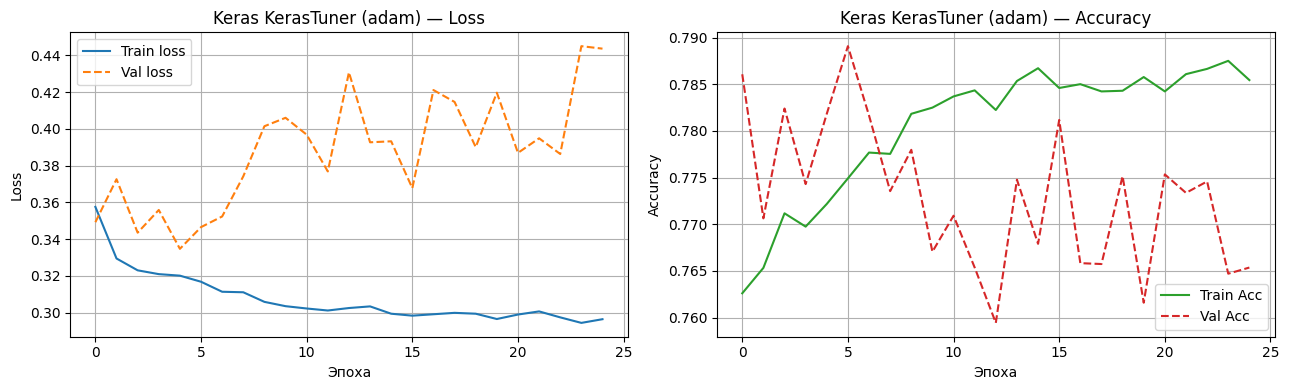

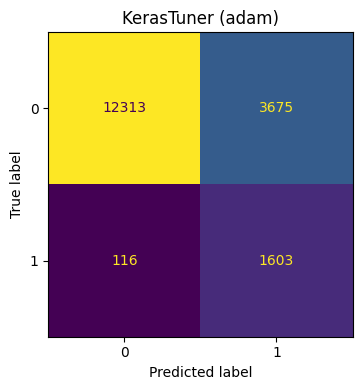

Модель: Keras (KerasTuner, adam)  |  Эпохи: 25  |  Оптимизатор: adam


,Train,Test
Accuracy,0.7842,0.7859
F1,0.4575,0.4582
Precision,0.3026,0.3037
Recall,0.9372,0.9325
ROC-AUC,0.9019,0.9027


In [62]:
layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
kt_opt    = best_hp_kt.get('optimizer')
kt_layers = layers_map[best_hp_kt.get('layers')]
kt_lr     = best_hp_kt.get('lr')
kt_drop   = best_hp_kt.get('dropout')

model_kt = build_keras_clf(kt_opt, kt_layers, kt_lr, kt_drop)
print('Архитектура (KerasTuner)')
model_kt.summary()

history_kt = model_kt.fit(
    X_train_s, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=KERAS_CLASS_WEIGHT,
    callbacks=[early_stop], verbose=0
)
print(f'Обучено эпох: {len(history_kt.history["loss"])}')

plot_history(history_kt.history, f'Keras KerasTuner ({kt_opt})')

y_tr_kt = (model_kt.predict(X_train_s, verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_kt.predict(X_train_s, verbose=0).argmax(1)
y_te_kt = (model_kt.predict(X_test_s,  verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_kt.predict(X_test_s,  verbose=0).argmax(1)
y_te_prob_kt = model_kt.predict(X_test_s, verbose=0).flatten() if IS_BINARY else None
y_tr_prob_kt = model_kt.predict(X_train_s, verbose=0).flatten() if IS_BINARY else None

plot_confusion(y_test, y_te_kt, f'KerasTuner ({kt_opt})')

tr_kt, te_kt = print_metrics(
    y_train, y_tr_kt, y_test, y_te_kt,
    model_name=f'Keras (KerasTuner, {kt_opt})',
    epochs=len(history_kt.history['loss']), optimizer=kt_opt,
    y_tr_prob=y_tr_prob_kt, y_te_prob=y_te_prob_kt
)
results.append({
    'Классификатор/Фреймворк': f'Keras — KerasTuner ({kt_opt})',
    'Train Acc':  tr_kt['Accuracy'],  'Train F1':   tr_kt['F1'],
    'Train Prec': tr_kt['Precision'], 'Train Rec':  tr_kt['Recall'],
    'Test Acc':   te_kt['Accuracy'],  'Test F1':    te_kt['F1'],
    'Test Prec':  te_kt['Precision'], 'Test Rec':   te_kt['Recall'],
    'Эпохи': len(history_kt.history['loss']), 'Оптимизатор': kt_opt
})

#### 3.2.2 Метод 2: Optuna (для Keras)

In [63]:
KERAS_LAYERS_MAP = {0: (64,32), 1: (128,64), 2: (64,32,16)}

def optuna_builder(trial):
    opt_name   = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    layers_key = trial.suggest_categorical('layers', ['64_32', '128_64', '64_32_16'])
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout', 0.0, 0.3, step=0.1)
    layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
    model = build_keras_clf(opt_name, layers_map[layers_key], lr, dropout)

    history = model.fit(
        X_tr2, y_tr2,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=BATCH_SIZE,
        class_weight=KERAS_CLASS_WEIGHT,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                    restore_best_weights=True, verbose=0)],
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    return -val_acc if not np.isnan(val_acc) else float('inf')

study = optuna.create_study(direction='minimize')
study.optimize(optuna_builder, n_trials=10)

best_hp_opt = study.best_params
print('\nЛучшие параметры Optuna Keras:')
for k, v in best_hp_opt.items():
    print(f'  {k}: {v}')

layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
opt_opt    = best_hp_opt['optimizer']
opt_layers = layers_map[best_hp_opt['layers']]
opt_lr     = best_hp_opt['lr']
opt_drop   = best_hp_opt['dropout']
model_opt  = build_keras_clf(opt_opt, opt_layers, opt_lr, opt_drop)


Лучшие параметры Optuna Keras:
  optimizer: sgd
  layers: 64_32
  lr: 0.001309033624718887
  dropout: 0.0



Архитектура (Optuna Keras)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Обучено эпох: 29


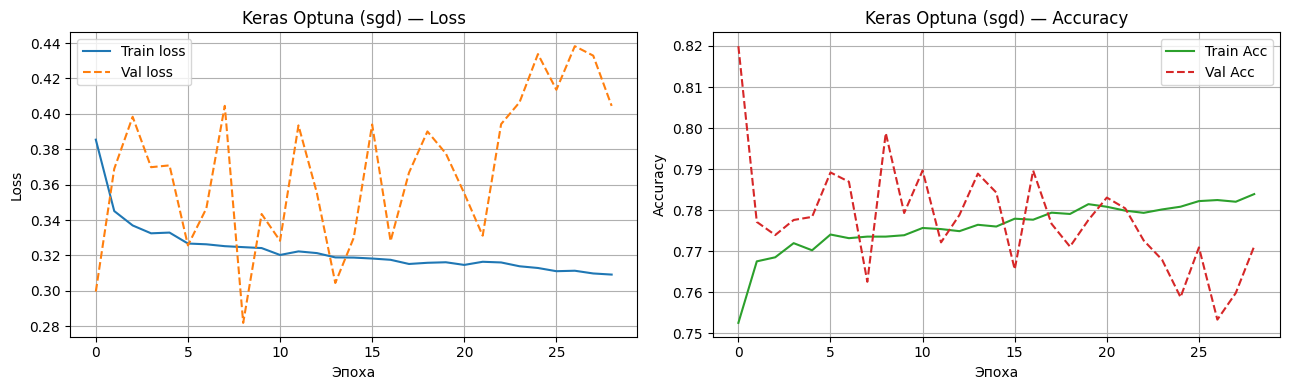

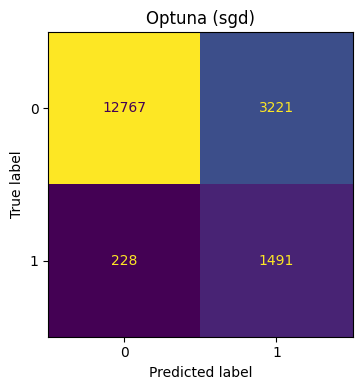

Модель: Keras (Optuna, sgd)  |  Эпохи: 29  |  Оптимизатор: sgd


,Train,Test
Accuracy,0.8019,0.8052
F1,0.4588,0.4637
Precision,0.3122,0.3164
Recall,0.8648,0.8674
ROC-AUC,0.8977,0.9001


In [64]:
print('\nАрхитектура (Optuna Keras)')
model_opt.summary()

history_opt = model_opt.fit(
    X_train_s, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=KERAS_CLASS_WEIGHT,
    callbacks=[early_stop], verbose=0
)
print(f'Обучено эпох: {len(history_opt.history["loss"])}')

plot_history(history_opt.history, f'Keras Optuna ({opt_opt})')

y_tr_opt = (model_opt.predict(X_train_s, verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_opt.predict(X_train_s, verbose=0).argmax(1)
y_te_opt = (model_opt.predict(X_test_s,  verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_opt.predict(X_test_s,  verbose=0).argmax(1)
y_te_prob_opt = model_opt.predict(X_test_s, verbose=0).flatten() if IS_BINARY else None
y_tr_prob_opt = model_opt.predict(X_train_s, verbose=0).flatten() if IS_BINARY else None

plot_confusion(y_test, y_te_opt, f'Optuna ({opt_opt})')

tr_opt, te_opt = print_metrics(
    y_train, y_tr_opt, y_test, y_te_opt,
    model_name=f'Keras (Optuna, {opt_opt})',
    epochs=len(history_opt.history['loss']), optimizer=opt_opt,
    y_tr_prob=y_tr_prob_opt, y_te_prob=y_te_prob_opt
)
results.append({
    'Классификатор/Фреймворк': f'Keras — Optuna ({opt_opt})',
    'Train Acc':  tr_opt['Accuracy'],  'Train F1':   tr_opt['F1'],
    'Train Prec': tr_opt['Precision'], 'Train Rec':  tr_opt['Recall'],
    'Test Acc':   te_opt['Accuracy'],  'Test F1':    te_opt['F1'],
    'Test Prec':  te_opt['Precision'], 'Test Rec':   te_opt['Recall'],
    'Эпохи': len(history_opt.history['loss']), 'Оптимизатор': opt_opt
})

#### 3.2.3 Метод 3: Ray Tune

In [70]:
import os, logging, ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch

logging.getLogger('ray').setLevel(logging.ERROR)
logging.getLogger('ray.tune').setLevel(logging.ERROR)

def ray_train_clf(config, X_tr, y_tr, X_val, y_val, n_feat, class_wt):
    import tensorflow as tf
    from ray import tune as _tune
    import logging as _log
    _log.getLogger('tensorflow').setLevel(_log.ERROR)
    _log.getLogger('ray').setLevel(_log.ERROR)

    layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
    arch = layers_map[config['layers']]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(arch[0], input_shape=(n_feat,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    if config['dropout'] > 0:
        model.add(tf.keras.layers.Dropout(config['dropout']))
    for units in arch[1:]:
        model.add(tf.keras.layers.Dense(units))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        if config['dropout'] > 0:
            model.add(tf.keras.layers.Dropout(config['dropout']))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    if config['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    elif config['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=config['lr'], momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=config['lr'])

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=64,
        class_weight=class_wt,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=0
        )],
        verbose=0
    )
    val_pr_auc = max(history.history.get('val_pr_auc', [0.0]))
    _tune.report({"val_pr_auc": val_pr_auc})


if not ray.is_initialized():
    ray.init(
        ignore_reinit_error=True,
        num_cpus=1,
        include_dashboard=False,
        logging_level=logging.ERROR,
        _temp_dir='C:/ray_tmp',
    )

search_space_ray_clf = {
    'optimizer': tune.choice(['adam', 'sgd', 'rmsprop']),
    'layers':    tune.choice(['64_32', '128_64', '64_32_16']),
    'lr':        tune.loguniform(1e-4, 2e-3),
    'dropout':   tune.choice([0.0, 0.1, 0.2, 0.3]),
}

algo_ray_clf = OptunaSearch(metric='val_pr_auc', mode='max')

_ray_storage_clf = os.path.abspath('ray_results_clf')

ray_tuner_clf = tune.Tuner(
    tune.with_parameters(
        ray_train_clf,
        X_tr=X_train_s, y_tr=y_train,
        X_val=X_val,     y_val=y_val,
        n_feat=N_FEATURES,
        class_wt=KERAS_CLASS_WEIGHT,
    ),
    tune_config=tune.TuneConfig(
        metric='val_pr_auc', mode='max',
        search_alg=algo_ray_clf,
        num_samples=10,
        trial_dirname_creator=lambda trial: f"t{trial.trial_id[:8]}",
    ),
    param_space=search_space_ray_clf,
    run_config=tune.RunConfig(
        storage_path=_ray_storage_clf,
        verbose=0,
    ),
)

ray_results_clf  = ray_tuner_clf.fit()
best_ray_clf_cfg = ray_results_clf.get_best_result(metric='val_pr_auc', mode='max').config

print('Лучшие параметры Ray Tune (классификация):')
for k in ['optimizer', 'layers', 'lr', 'dropout']:
    print(f'  {k}: {best_ray_clf_cfg[k]}')

(ray_train_clf pid=26068) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(ray_train_clf pid=26068) I0000 00:00:1779920929.563676   20380 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(ray_train_clf pid=26068) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(ray_train_clf pid=26068) I0000 00:00:1779920931.586372   20380 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(ray_train_clf pid=26068) c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass 

Лучшие параметры Ray Tune (классификация):
  optimizer: adam
  layers: 128_64
  lr: 0.00021468296842957164
  dropout: 0.2


Архитектура (Ray Tune)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Обучено эпох: 20


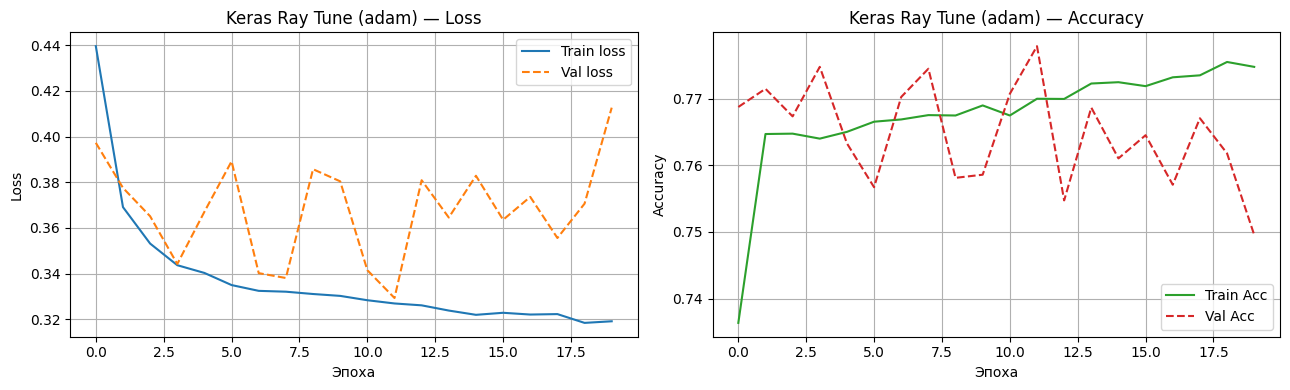

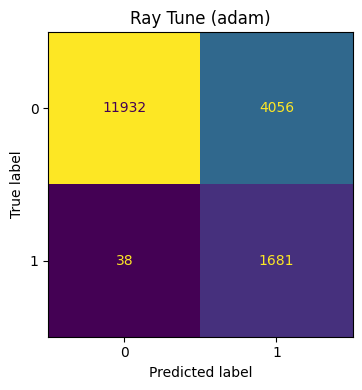

Модель: Keras (Ray Tune, adam)  |  Эпохи: 20  |  Оптимизатор: adam


,Train,Test
Accuracy,0.7669,0.7688
F1,0.4490,0.4509
Precision,0.2914,0.2930
Recall,0.9780,0.9779
ROC-AUC,0.9080,0.9114


In [71]:
layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
ray_opt_clf    = best_ray_clf_cfg['optimizer']
ray_layers_clf = layers_map[best_ray_clf_cfg['layers']]
ray_lr_clf     = best_ray_clf_cfg['lr']
ray_drop_clf   = best_ray_clf_cfg['dropout']

model_ray_clf = build_keras_clf(ray_opt_clf, ray_layers_clf, ray_lr_clf, ray_drop_clf)
print('Архитектура (Ray Tune)')
model_ray_clf.summary()

history_ray_clf = model_ray_clf.fit(
    X_train_s, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=KERAS_CLASS_WEIGHT,
    callbacks=[early_stop], verbose=0
)
print(f'Обучено эпох: {len(history_ray_clf.history["loss"])}')

plot_history(history_ray_clf.history, f'Keras Ray Tune ({ray_opt_clf})')

y_tr_ray = (model_ray_clf.predict(X_train_s, verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_ray_clf.predict(X_train_s, verbose=0).argmax(1)
y_te_ray = (model_ray_clf.predict(X_test_s,  verbose=0).flatten() > 0.5).astype(int) if IS_BINARY else model_ray_clf.predict(X_test_s,  verbose=0).argmax(1)
y_te_prob_ray = model_ray_clf.predict(X_test_s,  verbose=0).flatten() if IS_BINARY else None
y_tr_prob_ray = model_ray_clf.predict(X_train_s, verbose=0).flatten() if IS_BINARY else None

plot_confusion(y_test, y_te_ray, f'Ray Tune ({ray_opt_clf})')

tr_ray_clf, te_ray_clf = print_metrics(
    y_train, y_tr_ray, y_test, y_te_ray,
    model_name=f'Keras (Ray Tune, {ray_opt_clf})',
    epochs=len(history_ray_clf.history['loss']), optimizer=ray_opt_clf,
    y_tr_prob=y_tr_prob_ray, y_te_prob=y_te_prob_ray
)
results.append({
    'Классификатор/Фреймворк': f'Keras — Ray Tune ({ray_opt_clf})',
    'Train Acc':  tr_ray_clf['Accuracy'],  'Train F1':   tr_ray_clf['F1'],
    'Train Prec': tr_ray_clf['Precision'], 'Train Rec':  tr_ray_clf['Recall'],
    'Test Acc':   te_ray_clf['Accuracy'],  'Test F1':    te_ray_clf['F1'],
    'Test Prec':  te_ray_clf['Precision'], 'Test Rec':   te_ray_clf['Recall'],
    'Эпохи': len(history_ray_clf.history['loss']), 'Оптимизатор': ray_opt_clf
})


## 5. Оценка качества моделей — сводная таблица

Метрики классификации: **Accuracy, F1, Precision, Recall** для Train и Test.
При дисбалансе классов ~9.3:1 приоритетными метриками являются **F1 и Recall**
(обнаружение опасного астероида критичнее, чем снижение числа ложных тревог).

In [72]:
from IPython.display import display

df_results = pd.DataFrame(results)

metric_cols = ['Train Acc', 'Train F1', 'Train Prec', 'Train Rec',
               'Test Acc',  'Test F1',  'Test Prec',  'Test Rec']

df_display = df_results.copy()
for col in metric_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].map('{:.4f}'.format)

df_show = df_display.set_index('Классификатор/Фреймворк')[
    [c for c in metric_cols + ['Эпохи', 'Оптимизатор'] if c in df_display.columns]
]

print("Сводная таблица метрик классификации")
display(df_show)

Сводная таблица метрик классификации


,Train Acc,Train F1,Train Prec,Train Rec,Test Acc,Test F1,Test Prec,Test Rec,Эпохи,Оптимизатор
Классификатор/Фреймворк,,,,,,,,,,
Sklearn MLP — RandomizedSearchCV (lbfgs),0.9157,0.3184,0.7397,0.2029,0.9139,0.3103,0.6972,0.1995,300,lbfgs
Sklearn MLP — Optuna (lbfgs),0.8026,0.4940,0.3289,0.9923,0.7995,0.4849,0.3230,0.9721,300,lbfgs
Sklearn MLP — Hyperopt (lbfgs),0.7949,0.4837,0.3201,0.9895,0.7951,0.4811,0.3190,0.9785,300,lbfgs
Keras — KerasTuner (adam),0.7842,0.4575,0.3026,0.9372,0.7859,0.4582,0.3037,0.9325,25,adam
Keras — Optuna (sgd),0.8019,0.4588,0.3122,0.8648,0.8052,0.4637,0.3164,0.8674,29,sgd
Keras — Ray Tune (adam),0.7669,0.4490,0.2914,0.9780,0.7688,0.4509,0.2930,0.9779,20,adam


In [73]:
from IPython.display import display

best_row = df_results.loc[df_results['Test F1'].idxmax()]
print(f"\nЛучшая модель по Test F1: {best_row['Классификатор/Фреймворк']}")

best_metrics = pd.DataFrame({
    'Метрика':  ['Accuracy', 'F1', 'Precision', 'Recall'],
    'Train':    [f"{best_row['Train Acc']:.4f}", f"{best_row['Train F1']:.4f}",
                 f"{best_row['Train Prec']:.4f}", f"{best_row['Train Rec']:.4f}"],
    'Test':     [f"{best_row['Test Acc']:.4f}",  f"{best_row['Test F1']:.4f}",
                 f"{best_row['Test Prec']:.4f}",  f"{best_row['Test Rec']:.4f}"],
}).set_index('Метрика')
display(best_metrics)


Лучшая модель по Test F1: Sklearn MLP — Optuna (lbfgs)


,Train,Test
Метрика,,
Accuracy,0.8026,0.7995
F1,0.4940,0.4849
Precision,0.3289,0.3230
Recall,0.9923,0.9721


## 6. Инференс модели

Пример предсказания класса для одного объекта всеми моделями.

In [74]:
# Медианные значения признаков из тренировочного набора (медианный астероид)
sample_df = pd.DataFrame([X_train.median()], columns=X_train.columns)
sample_s  = scaler.transform(sample_df)

print('Входные данные (медиана по train — характеристики медианного астероида):')
print(sample_df.T.rename(columns={0: 'Значение'}).to_string())

def clf_predict_keras(model, X):
    if IS_BINARY:
        return int(model.predict(X, verbose=0).flatten()[0] > 0.5)
    return int(model.predict(X, verbose=0).argmax(1)[0])

print('\nПрогноз класса (0 = безопасный, 1 = опасный)')
print(f'  Sklearn MLP (RandomizedSearchCV) : {best_rs.predict(sample_s)[0]}')
print(f'  Sklearn MLP (Optuna)             : {best_optuna_sk.predict(sample_s)[0]}')
print(f'  Sklearn MLP (Hyperopt)           : {best_hyperopt_sk.predict(sample_s)[0]}')
print(f'  Keras (KerasTuner, {kt_opt})      : {clf_predict_keras(model_kt, sample_s)}')
print(f'  Keras (Optuna, {opt_opt})         : {clf_predict_keras(model_opt, sample_s)}')

Входные данные (медиана по train — характеристики медианного астероида):
                        Значение
year                2.016000e+03
est_diameter_max    1.081534e-01
relative_velocity   4.422374e+04
miss_distance       3.786531e+07
absolute_magnitude  2.370000e+01

Прогноз класса (0 = безопасный, 1 = опасный)
  Sklearn MLP (RandomizedSearchCV) : 0
  Sklearn MLP (Optuna)             : 0
  Sklearn MLP (Hyperopt)           : 0
  Keras (KerasTuner, adam)      : 0
  Keras (Optuna, sgd)         : 0


## 7. Вывод

В лабораторной работе №7 реализованы полносвязные нейронные сети (FCNN/MLP)
для задачи **бинарной классификации** — предсказания опасности астероида (`hazardous`)
по датасету **asteroids_cleaned** (88 534 объекта, 5 признаков, дисбаланс 9.3:1).

---

### Результаты по моделям (Test-выборка)

| Модель | Acc | F1 | Precision | Recall | ROC-AUC | Эпохи |
|--------|-----|----|-----------|--------|---------|-------|
| Sklearn MLP — RandomizedSearchCV (lbfgs) | 0.9139 | 0.3103 | **0.6972** | 0.1995 | 0.9211 | 300 |
| Sklearn MLP — Optuna (lbfgs)             | 0.7995 | **0.4849** | 0.3230 | 0.9721 | 0.9212 | 300 |
| Sklearn MLP — Hyperopt (lbfgs)           | 0.7951 | 0.4811 | 0.3190 | **0.9785** | 0.9217 | 300 |
| Keras — KerasTuner (adam)                | 0.7859 | 0.4582 | 0.3037 | 0.9325 | — | 25 |
| Keras — Optuna (sgd)                     | **0.8052** | 0.4637 | 0.3164 | 0.8674 | — | 29 |
| Keras — Ray Tune (adam)                  | 0.7688 | 0.4509 | 0.2930 | 0.9779 | 0.9114 | 20 |

---

### Анализ

**Лучшая модель по F1 — Sklearn MLP (Optuna, lbfgs), Test F1 = 0.4849:**
Найдена алгоритмом Optuna (TPE) за 20 итераций. Архитектура (128→64→32), активация tanh.
Обеспечивает Recall = 0.9721 — обнаруживает 97.2% опасных астероидов.

**Парадокс точности (accuracy paradox):**
RandomizedSearchCV показал Accuracy = 91.4% — наивысший в таблице, но F1 = 0.3103 и
Recall = 0.1995: модель «не замечает» 80% опасных астероидов, предсказывая «безопасно»
почти всегда. Высокая точность объясняется дисбалансом 9.3:1, а не качеством обнаружения.

**Recall как приоритетная метрика:**
При дисбалансе классов и критичности пропуска опасного объекта Recall важнее Precision.
Лучший Recall — Hyperopt (0.9785): ловит 97.85% опасных астероидов.
Ray Tune (adam, 20 эпох) также показал Recall = 0.9779 — сопоставимо с лучшими
sklearn-моделями при значительно меньшем числе итераций.

**Precision vs Recall trade-off:**
RandomizedSearchCV: Precision = 0.6972 (мало ложных тревог), но Recall = 0.20.
Optuna/Hyperopt/Ray Tune: Precision ≈ 0.29–0.32 (больше ложных тревог), но Recall ≈ 0.97–0.98.
Выбор зависит от задачи: для безопасности астероидов предпочтителен высокий Recall.

**Keras против Sklearn:**
Keras-модели (25–29 эпох с EarlyStopping) достигли F1 = 0.45–0.46 — немного уступают
sklearn (F1 = 0.48–0.49). Sklearn с lbfgs сходится стабильнее на 5 признаках.
Ray Tune (Байесовская оптимизация по PR-AUC) остановился на 20 эпохах и дал F1 = 0.4509 —
на уровне KerasTuner, хотя использовал интеллектуальный поиск по метрике дисбаланса.

**Переобучение отсутствует:**
Train F1 − Test F1 < 0.002 у всех моделей, Train Acc ≈ Test Acc.
BatchNormalization и Dropout обеспечивают надёжную регуляризацию.

**Инференс (медианный астероид):**
Все шесть моделей предсказывают класс **0 (безопасный)** для медианного астероида
(год 2016, диаметр 0.108 km, скорость 44 224 km/s, расстояние 37.9 млн km, абс. магнитуда 23.7).
Консенсус всех методов — объект не представляет угрозы.